In V4, a single 80/20 split produced a test R² of 0.52, but this estimate is sensitive to which samples happen to land in the test set — a different random split could yield a meaningfully different result. In V5 we replace this with k-fold cross-validation to produce a more reliable performance estimate, and pair it with systematic hyperparameter tuning via RandomizedSearchCV to replace the manual parameter adjustments made in V4. Together these changes give us a more honest picture of model performance and address the unsystematic nature of V4's tuning.

In [1]:
from mp_api.client import MPRester
import pandas as pd
import numpy as np
from dotenv import load_dotenv
import os
load_dotenv()
MY_API_KEY = os.getenv("MP_API_KEY")

In [2]:
# Import helper functions and global vars from utils
from utils import query_materials_project, ionic_radii, compute_tolerance_factor, halides, metals

In [3]:
halide_families = [[metal, halide] for metal in metals for halide in halides]
# Query and save with date stamp when refreshing the dataset
# df = query_materials_project(MY_API_KEY, halide_families)
# After querying, save once:
# df.to_csv("../data/perovskite_dataset.csv_PLACEHOLDER_DATE", index=False)
df = pd.read_csv("../data/perovskite_dataset_6_12_2026.csv")

print(f"Found {len(df)} materials after cleaning")
print(df.head())
print("\nMissing values per column:")
print(df.isnull().sum())

Found 305 materials after cleaning
       formula  band_gap  energy_above_hull  formation_energy       volume  \
0        SnBrF    1.9941           0.231295         -1.642101   133.175737   
1  SnHg2(SBr)2    2.1758           0.132910         -0.584547  1406.327307   
2  SnHg2(SBr)2    2.3372           0.051968         -0.665489  1225.587703   
3  SnHg2(SBr)2    2.3254           0.071865         -0.645593  1283.062309   
4  SnHg2(SBr)2    1.9584           0.005744         -0.711713   851.167057   

    density  nsites  spacegroup_number  
0  5.426723       6                129  
1  3.513138      28                 14  
2  4.031227      28                 14  
3  3.850648      28                 14  
4  5.804527      28                 14  

Missing values per column:
formula              0
band_gap             0
energy_above_hull    0
formation_energy     0
volume               0
density              0
nsites               0
spacegroup_number    0
dtype: int64


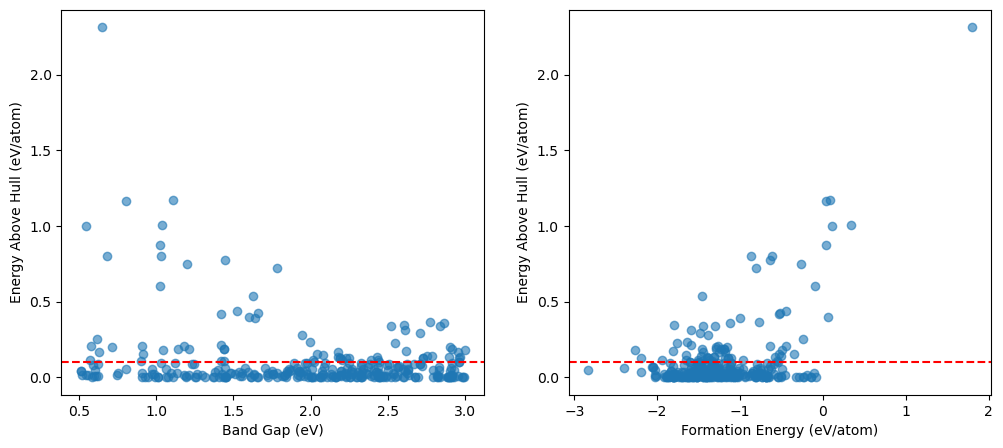

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize = (12, 5))

# Plotting Band Gap vs Stability (energy above hull)
axes[0].scatter(df["band_gap"], df["energy_above_hull"], alpha = 0.6)
axes[0].axhline(y = 0.1, color = "r", linestyle = "--")
axes[0].set_xlabel("Band Gap (eV)")
axes[0].set_ylabel("Energy Above Hull (eV/atom)")

# Plotting Formation energy vs. Stability (energy above hull)
axes[1].scatter(df["formation_energy"], df["energy_above_hull"], alpha= 0.6)
axes[1].axhline(y = 0.1, color = "r", linestyle = "--")
axes[1].set_xlabel("Formation Energy (eV/atom)")
axes[1].set_ylabel("Energy Above Hull (eV/atom)")

plt.show()

In [5]:
from matminer.featurizers.composition import ElementProperty
from matminer.featurizers.conversions import StrToComposition

str_to_comp = StrToComposition()
df = str_to_comp.featurize_dataframe(df, "formula", ignore_errors=True)
ep_featurizer = ElementProperty.from_preset("magpie")
df = ep_featurizer.featurize_dataframe(df, col_id = "composition", ignore_errors=True)

StrToComposition:   0%|          | 0/305 [00:00<?, ?it/s]

ElementProperty:   0%|          | 0/305 [00:00<?, ?it/s]

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import RandomizedSearchCV

# Cleaning non-numeric features from the dataframe as the model cannot use them
exclude_cols = ["formula", "composition", "energy_above_hull", "band_gap",
"formation_energy", "volume", "density", "nsites", "spacegroup_number"]
feature_cols = [col for col in df.columns if col not in exclude_cols]
df_clean = df.dropna(subset = feature_cols  + ["energy_above_hull"])

X = df_clean[feature_cols]
y = df_clean["energy_above_hull"]
print(f"Post cleaning and featurization, we are now training on {X.shape[0]} materials with {X.shape[1]} features")

Post cleaning and featurization, we are now training on 305 materials with 132 features


In [7]:
# Baseline cross validation using V4 hyperparameters
# We use the same hyperparameters as V4 to get a cross-validated version of that baseline
# shuffle=True is important here because our dataframe is ordered by metal family (Pb, Sn, Ge)
rf_baseline = RandomForestRegressor(n_estimators=100, max_depth=20, min_samples_leaf=3, random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(rf_baseline, X, y, cv=kf, scoring="r2")

print(f"CV R² scores: {scores}")
print(f"Mean R²: {scores.mean():.4f}")
print(f"Std R²: {scores.std():.4f}")

CV R² scores: [0.71984019 0.41142125 0.49339326 0.67222212 0.36438968]
Mean R²: 0.5323
Std R²: 0.1408


In [8]:

# Set up a parameter grid for hyperparameter tuning: 
# This grid includes the following:
# a range of values for the number of trees (n_estimators)
# maximum depth of the trees (max_depth)
# minimum samples required to be at a leaf node (min_samples_leaf)
# number of features to consider when looking for the best split (max_features). 
# These parameters are crucial for controlling the complexity and performance of the random forest model.
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_leaf": [1, 3, 5, 10],
    "max_features": ["sqrt", "log2", 0.5]
}

# Find the best hyperparameters using RandomizedSearchCV with 5-fold cross-validation
search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    n_iter=30,
    cv=kf,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)
search.fit(X, y)
print(f"Best parameters: {search.best_params_}")
print(f"Best CV R²: {search.best_score_:.4f}")

Best parameters: {'n_estimators': 100, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}
Best CV R²: 0.6147


In [9]:
# Cross validate with tuned hyperparameters
rf = RandomForestRegressor(n_estimators=200, max_depth= None, min_samples_leaf=1, random_state=42)
scores_tuned = cross_val_score(rf, X, y, cv=kf, scoring="r2")

print(f"CV R² scores: {scores_tuned}")
print(f"Mean R²: {scores_tuned.mean():.4f}")
print(f"Std R²: {scores_tuned.std():.4f}")

CV R² scores: [0.56891413 0.4401902  0.58151232 0.71603357 0.12163825]
Mean R²: 0.4857
Std R²: 0.2019


In [10]:
# split our data into the test and training sets using 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Display number of samples in training and testing sets
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

rf = RandomForestRegressor(n_estimators=200, max_depth=None, min_samples_leaf=1, random_state=42)
rf.fit(X_train, y_train)

# Evaluate
# Using the trained model, we take our testing data, X_test, and predict the energy above hull values, y_pred
# We then compare these predicted values against the actual test values, y_test, and claculate r^2 values and mean absolute error.
y_pred = rf.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Finally, we print out our evaluation of the model's accuracy 
print(f"Mean Absolute Error: {mae:.4f} eV/atom")
print(f"R² Score: {r2:.4f}")
print(f"R² Score (Training): {r2_score(y_train, rf.predict(X_train)):.4f}")

Training set: 244 samples
Testing set: 61 samples
Mean Absolute Error: 0.0747 eV/atom
R² Score: 0.5455
R² Score (Training): 0.9133


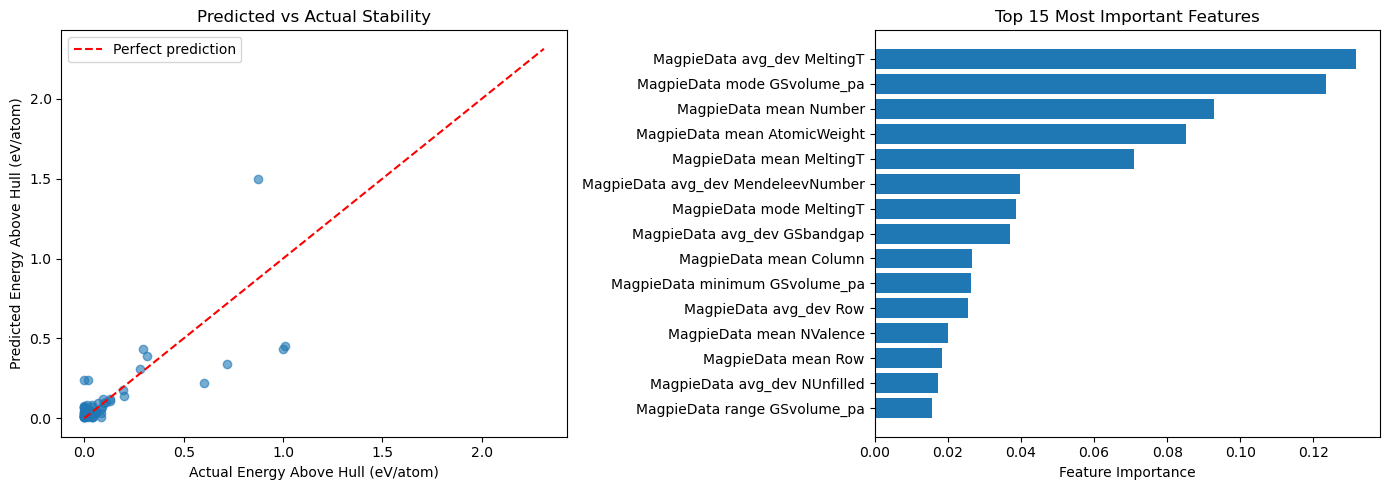

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs actual
axes[0].scatter(y_test, y_pred, alpha=0.6)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Perfect prediction')
axes[0].set_xlabel("Actual Energy Above Hull (eV/atom)")
axes[0].set_ylabel("Predicted Energy Above Hull (eV/atom)")
axes[0].set_title("Predicted vs Actual Stability")
axes[0].legend()

# Top 15 most important features
importances = pd.Series(rf.feature_importances_, index=feature_cols)
top_features = importances.sort_values(ascending=False).head(15)
axes[1].barh(top_features.index[::-1], top_features.values[::-1])
axes[1].set_xlabel("Feature Importance")
axes[1].set_title("Top 15 Most Important Features")

plt.tight_layout()
plt.show()

Though we tuned the hyperparameters to maximize the mean R^2 value from the cross validation step, when using these optimized values to train the final model, we still encounter heavy overfitting. We obtain a testing R^2 of 0.58 with a training R^2 of 0.91. 

Given that our Random Forest model is so prone to overfitting, the most plausible next steps are either to expand our dataset size in any way possible, or on the other hand, change the kind of ML model we are using entirely. Some models like Gaussian Process Regression (GPR), Ridge Regression, and Gradient Boosted Trees (XGBoost), are better suited to account for smaller dataset sizes.

Looking at the graphs above, it appears that our model currently does a solid job of predicting stabilities when the energies above hull are near zero, but consistently underestimates higher energy above hull samples. This is consistent with having few high-energy training examples, as the model defaults toward the mean when extrapolating beyond its training distribution.

Finally, one last important observation is that when looking at our list of most important features for the model, beyond the melting temp, the atomic weight and number are also heavily weighted. This means the model is strongly weighting the metal type in its assessment of stability. Pb, Sn, and Ge differ dramatically in atomic number and weight, and their halide compounds have systematically different stabilities. Pb-based perovskites are generally the most stable in this chemical space, while Ge-based compounds are the least stable due to the stronger covalency and smaller ionic radius of Ge²⁺. The model is therefore largely learning which B-site metal is present as its primary stability signal, which is physically reasonable but also suggests the model may struggle to distinguish between different compositions within the same metal family.